<a href="https://colab.research.google.com/github/eddiejaques/ml-code-samples/blob/main/Security%20Breaches%20Dataset/data_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Security Data — Logistic Regression (Multiple Logistic Regression)

## Dataset
Data sourced from `security_data_10000.csv` (synthetic data generated from original class dataset).

| Column | Description |
|--------|-------------|
| Sector | Industry sector of the company |
| CEO_Gender | Gender of the CEO (Male/Female) |
| Size | Company size (Large, Medium, Small) |
| Security_Invest | Security investment amount |
| Security_Breach_Att | Number of security breach attempts |
| Succ_Sec_Breaches | Number of successful security breaches |
| Sec_Rating | Overall security rating (High/Medium/Low) |
| CEO_Sec_Exp | CEO's level of security experience (High/Medium/Low) |
| LOT_in_Business | Length of time in business (years) |
| Stock_Market | Whether the company is listed on the stock market (Yes/No) |

---

## Objective
Predict whether a company is **listed on the stock market (Yes/No)** using all available features.

**Target variable:** `Stock_Market` (Yes = True / No = False)

---

## Data Analysis Plan

1.  **Load Data** — Read CSV into DataFrame
2.  **Train-Test Split** — Split before any feature engineering
3.  **Create Binary Label** — Encode `Stock_Market` as True/False
4.  **Drop Target from Features** — Remove `Stock_Market` from input features
5.  **Encode Categorical Features** — One-hot encode remaining categorical columns
6.  **Fit Logistic Regression** — Use `class_weight='balanced'` to handle class imbalance
7.  **Evaluate** — Confusion matrix and classification report on train and test

## Step 1 — Load Dataset

In [686]:
#LOAD THE DATASET


import pandas as pd

file_url = "https://raw.githubusercontent.com/eddiejaques/ml-code-samples/refs/heads/main/Security%20Breaches%20Dataset/security_data_10000V2.csv"

security_df = pd.read_csv(file_url)

security_df.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Hospitality,Male,Large,32,60,17,Medium,Low,11,No
1,Health Care,Male,Small,56,54,17,Medium,Low,18,Yes
2,Health Care,Male,Medium,24,63,16,High,Low,5,Yes
3,Hospitality,Male,Medium,26,42,18,Low,Low,3,No
4,Banking,Male,Medium,23,54,19,Medium,Low,4,Yes


## Step 2 — Train-Test Split
Split performed **before** any feature engineering to prevent data leakage.

In [687]:
from sklearn.model_selection import train_test_split
security_df_train, security_df_test = train_test_split(security_df, test_size=0.2, random_state=42)

### Step 3 — Exploratory Data Analysis (EDA)

In [688]:
security_df_train.describe()

,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
count,8000.000000,8000.000000,8000.00000,8000.000000
mean,55.676125,41.996500,13.99250,8.169625
std,45.670890,22.574824,9.25629,6.691072
min,12.000000,9.000000,0.00000,1.000000
25%,25.000000,24.000000,7.00000,3.000000
50%,42.000000,38.000000,12.00000,6.000000
75%,70.000000,55.000000,19.00000,12.000000
max,450.000000,223.000000,97.00000,25.000000


In [689]:
security_df_train.isna().sum()

Sector                 0
CEO_Gender             0
Size                   0
Security_Invest        0
Security_Breach_Att    0
Succ_Sec_Breaches      0
Sec_Rating             0
CEO_Sec_Exp            0
LOT_in_Business        0
Stock_Market           0
dtype: int64

## Step 4 — Create Binary Label
Encode `Stock_Market` as a boolean: `True` = Yes, `False` = No.
This will be the target variable for the logistic regression model.

In [690]:
security_df_train_label = (security_df_train["Stock_Market"] == 'Yes')

security_df_test_label = (security_df_test["Stock_Market"] =='Yes')

In [691]:
security_df_train.shape

(8000, 10)

## Step 5 — Drop Target Column from Features
`Stock_Market` must be removed from the input features — it is the target variable, not a predictor.

In [692]:
security_df_train = security_df_train.drop("Stock_Market", axis=1)
security_df_train.shape

(8000, 9)

In [693]:
security_df_test = security_df_test.drop("Stock_Market", axis=1)
security_df_test.shape

(2000, 9)

In [694]:
numerical_cols = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches", "LOT_in_Business"]
categorical_cols = ["Sector", "Size", "Sec_Rating", "CEO_Sec_Exp", "CEO_Gender"]

In [695]:
security_df_train.describe()

,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
count,8000.000000,8000.000000,8000.00000,8000.000000
mean,55.676125,41.996500,13.99250,8.169625
std,45.670890,22.574824,9.25629,6.691072
min,12.000000,9.000000,0.00000,1.000000
25%,25.000000,24.000000,7.00000,3.000000
50%,42.000000,38.000000,12.00000,6.000000
75%,70.000000,55.000000,19.00000,12.000000
max,450.000000,223.000000,97.00000,25.000000


In [696]:
security_df_train.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business
9254,Health Care,Male,Large,133,35,7,Medium,Low,6
1561,Banking,Male,Small,12,51,24,Low,High,10
1670,Hospitality,Male,Medium,32,26,10,Low,Medium,2
6087,Banking,Female,Large,43,28,7,Low,High,7
6669,Banking,Male,Small,15,18,9,Low,High,4


## Step 6 — Impute

In [697]:
print(security_df_train.shape)
print(security_df_test.shape)


from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

security_df_train_num = pd.DataFrame(imputer.fit_transform(security_df_train[numerical_cols]), columns=numerical_cols)

security_df_test_num = pd.DataFrame(imputer.transform(security_df_test[numerical_cols]), columns=numerical_cols)

security_df_train_final = pd.concat([security_df_train_num.reset_index(drop=True), security_df_train[categorical_cols].reset_index(drop=True)], axis=1)

security_df_test_final = pd.concat([security_df_test_num.reset_index(drop=True), security_df_test[categorical_cols].reset_index(drop=True)], axis=1)

security_df_train_final.head()


(8000, 9)
(2000, 9)


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business,Sector,Size,Sec_Rating,CEO_Sec_Exp,CEO_Gender
0,133.0,35.0,7.0,6.0,Health Care,Large,Medium,Low,Male
1,12.0,51.0,24.0,10.0,Banking,Small,Low,High,Male
2,32.0,26.0,10.0,2.0,Hospitality,Medium,Low,Medium,Male
3,43.0,28.0,7.0,7.0,Banking,Large,Low,High,Female
4,15.0,18.0,9.0,4.0,Banking,Small,Low,High,Male


## Step 7 — Remove Outliers

In [698]:
print("Shape of security_df_train_final:", security_df_train_final.shape)
print("Shape of security_df_test_final:", security_df_test_final.shape)

from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)

outliers = isolation_forest.fit_predict(security_df_train_final[numerical_cols])

print ("Number of outliers detected:", (outliers == -1).sum())

security_df_train_final = security_df_train_final[outliers == 1]

security_df_train_label = security_df_train_label[outliers == 1]

print("Shape of security_df_train_final:", security_df_train_final.shape)

print("Shape of security_df_test_final:", security_df_test_final.shape)

Shape of security_df_train_final: (8000, 9)
Shape of security_df_test_final: (2000, 9)
Number of outliers detected: 1677
Shape of security_df_train_final: (6323, 9)
Shape of security_df_test_final: (2000, 9)


## Step 8 — Encode Categorical Features
One-hot encode all remaining categorical columns. `dtype=int` ensures 0/1 output instead of True/False.
Original categorical columns are dropped after encoding to avoid duplication.

In [699]:

security_df_train_cat = pd.get_dummies( security_df_train_final[categorical_cols], dtype=int)
security_df_test_cat = pd.get_dummies(security_df_test_final[categorical_cols], dtype=int)

# Align columns after one-hot encoding
aligned_cols = list(set(security_df_train_cat.columns) | set(security_df_test_cat.columns))
security_df_train_cat = security_df_train_cat.reindex(columns=aligned_cols, fill_value=0)
security_df_test_cat = security_df_test_cat.reindex(columns=aligned_cols, fill_value=0)

security_df_train_final = pd.concat([security_df_train_final[numerical_cols].reset_index(drop=True), security_df_train_cat.reset_index(drop=True)], axis=1)
security_df_test_final = pd.concat([security_df_test_final[numerical_cols].reset_index(drop=True), security_df_test_cat.reset_index(drop=True)], axis=1)

print("Shape of security_df_train_final:", security_df_train_final.shape)

print("Shape of security_df_test_final:", security_df_test_final.shape)

security_df_train_final.head()

Shape of security_df_train_final: (6323, 18)
Shape of security_df_test_final: (2000, 18)


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business,CEO_Sec_Exp_Medium,Sector_Health Care,CEO_Gender_Female,CEO_Sec_Exp_High,Size_Medium,Sec_Rating_Medium,Sec_Rating_High,CEO_Sec_Exp_Low,Size_Small,Size_Large,CEO_Gender_Male,Sector_Hospitality,Sec_Rating_Low,Sector_Banking
0,133.0,35.0,7.0,6.0,0,1,0,0,0,1,0,1,0,1,1,0,0,0
1,12.0,51.0,24.0,10.0,0,0,0,1,0,0,0,0,1,0,1,0,1,1
2,32.0,26.0,10.0,2.0,1,0,0,0,1,0,0,0,0,0,1,1,1,0
3,43.0,28.0,7.0,7.0,0,0,1,1,0,0,0,0,0,1,0,0,1,1
4,15.0,18.0,9.0,4.0,0,0,0,1,0,0,0,0,1,0,1,0,1,1


## Step 9 — Scaling

In [700]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches", "LOT_in_Business"]

security_df_train_scaled = pd.DataFrame(scaler.fit_transform(security_df_train_final[numerical_cols]), columns=numerical_cols)

security_df_test_scaled = pd.DataFrame(scaler.transform(security_df_test_final[numerical_cols]), columns=numerical_cols)

security_df_train_final = pd.concat([security_df_train_final.drop(columns=numerical_cols), security_df_train_scaled], axis=1)

security_df_test_final =  pd.concat([security_df_test_final.drop(columns=numerical_cols), security_df_test_scaled], axis=1)

print("Shape of security_df_train_final:", security_df_train_final.shape)

print("Shape of security_df_test_final:", security_df_test_final.shape)

security_df_train_final.head()


Shape of security_df_train_final: (6323, 18)
Shape of security_df_test_final: (2000, 18)


,CEO_Sec_Exp_Medium,Sector_Health Care,CEO_Gender_Female,CEO_Sec_Exp_High,Size_Medium,Sec_Rating_Medium,Sec_Rating_High,CEO_Sec_Exp_Low,Size_Small,Size_Large,CEO_Gender_Male,Sector_Hospitality,Sec_Rating_Low,Sector_Banking,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
0,0,1,0,0,0,1,0,1,0,1,1,0,0,0,2.867724,-0.045668,-0.742894,-0.107486
1,0,0,0,1,0,0,0,0,1,0,1,0,1,1,-1.190388,0.990229,1.906380,0.741527
2,1,0,0,0,1,0,0,0,0,0,1,1,1,0,-0.519626,-0.628359,-0.275375,-0.956500
3,0,0,1,1,0,0,0,0,0,1,0,0,1,1,-0.150707,-0.498872,-0.742894,0.104767
4,0,0,0,1,0,0,0,0,1,0,1,0,1,1,-1.089774,-1.146308,-0.431215,-0.531993


## Step 10 — Fit Logistic Regression

In [701]:
from sklearn.linear_model import LogisticRegression

logistic_model = log_reg = LogisticRegression(class_weight="balanced", solver='liblinear', random_state=42)

logistic_model.fit(security_df_train_final, security_df_train_label)

security_df_train_label_pred = logistic_model.predict(security_df_train_final)

security_df_test_label_pred = logistic_model.predict(security_df_test_final)
print(f"Shape of security_df_test_final: {security_df_test_final.shape}")
print(f"Shape of security_df_test_label_pred: {security_df_test_label_pred.shape}")

Shape of security_df_test_final: (2000, 18)
Shape of security_df_test_label_pred: (2000,)


In [702]:
from sklearn.metrics import confusion_matrix, classification_report
print("Confusion Matrix - Train:")

print(confusion_matrix(security_df_train_label, security_df_train_label_pred))

print("Classification Report - Train:")

print(classification_report(security_df_train_label, security_df_train_label_pred))

print("Confusion Matrix - Test:")

print(confusion_matrix(security_df_test_label, security_df_test_label_pred))

print("Classification Report - Test:")

print(classification_report(security_df_test_label, security_df_test_label_pred))

Confusion Matrix - Train:
[[ 977  947]
 [2033 2366]]
Classification Report - Train:
              precision    recall  f1-score   support

       False       0.32      0.51      0.40      1924
        True       0.71      0.54      0.61      4399

    accuracy                           0.53      6323
   macro avg       0.52      0.52      0.50      6323
weighted avg       0.60      0.53      0.55      6323

Confusion Matrix - Test:
[[283 317]
 [635 765]]
Classification Report - Test:
              precision    recall  f1-score   support

       False       0.31      0.47      0.37       600
        True       0.71      0.55      0.62      1400

    accuracy                           0.52      2000
   macro avg       0.51      0.51      0.49      2000
weighted avg       0.59      0.52      0.54      2000



In [703]:
# Accuracy is not a good metric for imbalanced datasets, so we use macro-averaged precision, recall and F1.

report = classification_report(security_df_test_label, security_df_test_label_pred, output_dict=True)

print("Precision:", report['macro avg']['precision'])
print("Recall:",    report['macro avg']['recall'])
print("F1-Score:",  report['macro avg']['f1-score'])
print("Accuracy:",  report['accuracy'])

Precision: 0.507651448338629
Recall: 0.509047619047619
F1-Score: 0.4946486905986608
Accuracy: 0.524


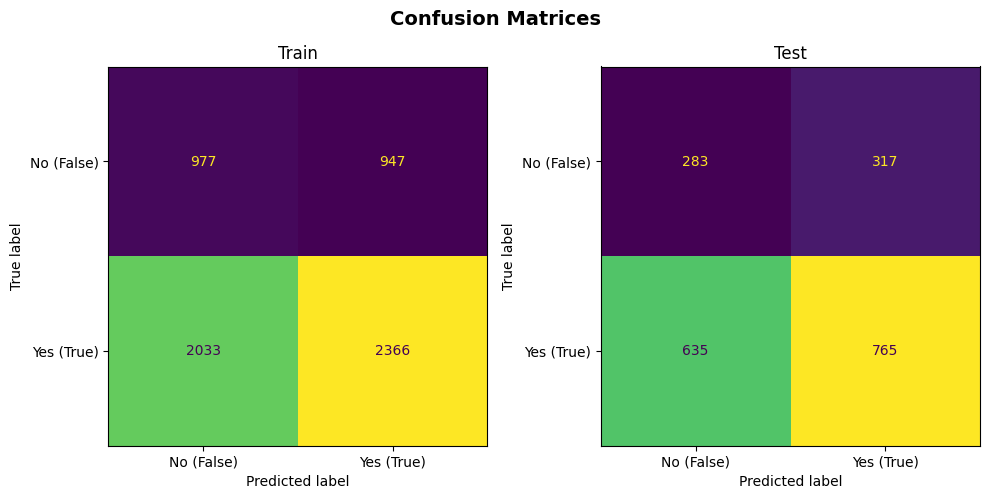

In [704]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")

datasets = [
    (security_df_train_label, security_df_train_label_pred, "Train"),
    (security_df_test_label,  security_df_test_label_pred,  "Test"),
]

for ax, (y_true, y_pred, title) in zip(axes.flat, datasets):
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["No (False)", "Yes (True)"],
        colorbar=False,
        ax=ax,
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Step 11 — Evaluate
- **Confusion matrix** — shows True/False Positives and Negatives
- **Precision** — of all predicted Male/Female, how many were correct
- **Recall** — of all actual Male/Female, how many were caught
- **F1-score** — harmonic mean of precision and recall

---

## Step 12 — Evaluate Ordinal Encoding Experiment
Re-run logistic regression replacing one-hot encoding for `Size`, `CEO_Sec_Exp`, and `Sec_Rating` with **OrdinalEncoder** (preserving natural order), while keeping one-hot encoding for `Sector` and `CEO_Gender`.

In [705]:
from sklearn.preprocessing import OrdinalEncoder

# Reload clean post-outlier-removal data (re-derive from original split)
security_df2 = pd.read_csv(file_url)
train2, test2 = train_test_split(security_df2, test_size=0.2, random_state=42)

label_train2 = (train2["Stock_Market"] == "Yes")
label_test2  = (test2["Stock_Market"] == "Yes")

train2 = train2.drop("Stock_Market", axis=1)
test2  = test2.drop("Stock_Market", axis=1)

numerical_cols2   = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches", "LOT_in_Business"]
ordinal_cols      = ["Size", "CEO_Sec_Exp", "Sec_Rating"]
onehot_cols2      = ["Sector", "CEO_Gender"]

# Impute numerics
from sklearn.impute import SimpleImputer
imputer2 = SimpleImputer(strategy="median")
train2_num = pd.DataFrame(imputer2.fit_transform(train2[numerical_cols2]), columns=numerical_cols2)
test2_num  = pd.DataFrame(imputer2.transform(test2[numerical_cols2]),      columns=numerical_cols2)

train2_combined = pd.concat([train2_num, train2[ordinal_cols + onehot_cols2].reset_index(drop=True)], axis=1)
test2_combined  = pd.concat([test2_num,  test2[ordinal_cols + onehot_cols2].reset_index(drop=True)], axis=1)

# Remove outliers (same IsolationForest config)
iso2 = IsolationForest(random_state=42)
mask2 = iso2.fit_predict(train2_combined[numerical_cols2])
train2_combined = train2_combined[mask2 == 1].reset_index(drop=True)
label_train2    = label_train2[mask2 == 1].reset_index(drop=True)

print(f"Train shape after outlier removal: {train2_combined.shape}")

# Ordinal encode Size / CEO_Sec_Exp / Sec_Rating
ordinal_categories = [
    ["Small", "Medium", "Large"],   # Size
    ["Low",   "Medium", "High"],    # CEO_Sec_Exp
    ["Low",   "Medium", "High"],    # Sec_Rating
]
enc = OrdinalEncoder(categories=ordinal_categories)
train2_ord = pd.DataFrame(enc.fit_transform(train2_combined[ordinal_cols]), columns=ordinal_cols)
test2_ord  = pd.DataFrame(enc.transform(test2_combined[ordinal_cols]),      columns=ordinal_cols)

# One-hot encode Sector / CEO_Gender
train2_ohe = pd.get_dummies(train2_combined[onehot_cols2], dtype=int)
test2_ohe  = pd.get_dummies(test2_combined[onehot_cols2],  dtype=int)
ohe_cols   = list(set(train2_ohe.columns) | set(test2_ohe.columns))
train2_ohe = train2_ohe.reindex(columns=ohe_cols, fill_value=0)
test2_ohe  = test2_ohe.reindex(columns=ohe_cols,  fill_value=0)

# Scale numerics
scaler2 = StandardScaler()
train2_scaled = pd.DataFrame(scaler2.fit_transform(train2_combined[numerical_cols2]), columns=numerical_cols2)
test2_scaled  = pd.DataFrame(scaler2.transform(test2_combined[numerical_cols2]),       columns=numerical_cols2)

# Assemble final feature matrices
X_train2 = pd.concat([train2_scaled, train2_ord.reset_index(drop=True), train2_ohe.reset_index(drop=True)], axis=1)
X_test2  = pd.concat([test2_scaled,  test2_ord,                          test2_ohe],                         axis=1)

print(f"X_train2 shape: {X_train2.shape}")
print(f"X_test2  shape: {X_test2.shape}")
X_train2.head()

Train shape after outlier removal: (6323, 9)
X_train2 shape: (6323, 12)
X_test2  shape: (2000, 12)


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business,Size,CEO_Sec_Exp,Sec_Rating,CEO_Gender_Female,Sector_Hospitality,Sector_Health Care,CEO_Gender_Male,Sector_Banking
0,2.867724,-0.045668,-0.742894,-0.107486,2.0,0.0,1.0,0,0,1,1,0
1,-1.190388,0.990229,1.906380,0.741527,0.0,2.0,0.0,0,0,0,1,1
2,-0.519626,-0.628359,-0.275375,-0.956500,1.0,1.0,0.0,0,1,0,1,0
3,-0.150707,-0.498872,-0.742894,0.104767,2.0,2.0,0.0,1,0,0,0,1
4,-1.089774,-1.146308,-0.431215,-0.531993,0.0,2.0,0.0,0,0,0,1,1


In [706]:
# Fit logistic regression with ordinal-encoded features
logistic_model2 = LogisticRegression(class_weight="balanced", solver="liblinear", random_state=42)
logistic_model2.fit(X_train2, label_train2)

pred_train2 = logistic_model2.predict(X_train2)
pred_test2  = logistic_model2.predict(X_test2)

print("=== Ordinal Encoding — Train ===")
print(confusion_matrix(label_train2, pred_train2))
print(classification_report(label_train2, pred_train2))

print("=== Ordinal Encoding — Test ===")
print(confusion_matrix(label_test2, pred_test2))
print(classification_report(label_test2, pred_test2))

=== Ordinal Encoding — Train ===
[[ 959  965]
 [2017 2382]]
              precision    recall  f1-score   support

       False       0.32      0.50      0.39      1924
        True       0.71      0.54      0.62      4399

    accuracy                           0.53      6323
   macro avg       0.52      0.52      0.50      6323
weighted avg       0.59      0.53      0.55      6323

=== Ordinal Encoding — Test ===
[[285 315]
 [635 765]]
              precision    recall  f1-score   support

       False       0.31      0.47      0.38       600
        True       0.71      0.55      0.62      1400

    accuracy                           0.53      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.59      0.53      0.54      2000



In [707]:
from sklearn.metrics import accuracy_score, f1_score

# One-hot model scores (from earlier cells)
ohe_test_acc = accuracy_score(security_df_test_label, security_df_test_label_pred)
ohe_test_f1  = f1_score(security_df_test_label, security_df_test_label_pred, average="macro")

# Ordinal model scores
ord_test_acc = accuracy_score(label_test2, pred_test2)
ord_test_f1  = f1_score(label_test2, pred_test2, average="macro")

comparison = pd.DataFrame({
    "Encoding":       ["One-Hot (baseline)", "Ordinal (Size/CEO_Sec_Exp/Sec_Rating)"],
    "Test Accuracy":  [f"{ohe_test_acc:.2%}", f"{ord_test_acc:.2%}"],
    "Test Macro F1":  [f"{ohe_test_f1:.2%}", f"{ord_test_f1:.2%}"],
})
comparison

,Encoding,Test Accuracy,Test Macro F1
0,One-Hot (baseline),52.40%,49.46%
1,Ordinal (Size/CEO_Sec_Exp/Sec_Rating),52.50%,49.60%


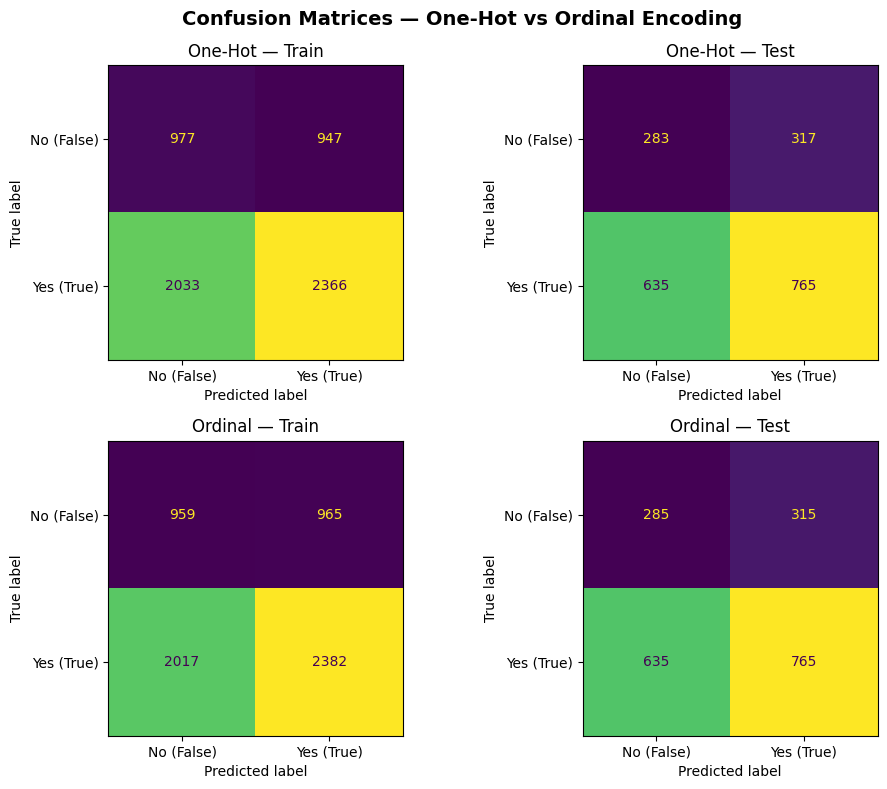

In [708]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Confusion Matrices — One-Hot vs Ordinal Encoding", fontsize=14, fontweight="bold")

datasets = [
    (security_df_train_label, security_df_train_label_pred, "One-Hot — Train"),
    (security_df_test_label,  security_df_test_label_pred,  "One-Hot — Test"),
    (label_train2,            pred_train2,                  "Ordinal — Train"),
    (label_test2,             pred_test2,                   "Ordinal — Test"),
]

for ax, (y_true, y_pred, title) in zip(axes.flat, datasets):
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["No (False)", "Yes (True)"],
        colorbar=False,
        ax=ax,
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Step 13 — Cross-Validation
5-fold cross-validation on the training data for both encoding strategies.  
Reports mean ± std for **accuracy** and **macro F1**.

In [709]:
from sklearn.model_selection import cross_validate

cv_results = {}

for name, X, y, model in [
    ("One-Hot",  security_df_train_final, security_df_train_label,
     LogisticRegression(class_weight="balanced", solver="liblinear", random_state=42)),
    ("Ordinal",  X_train2, label_train2,
     LogisticRegression(class_weight="balanced", solver="liblinear", random_state=42)),
]:
    scores = cross_validate(model, X, y, cv=5,
                            scoring=["accuracy", "f1_macro"],
                            return_train_score=False)
    cv_results[name] = {
        "Accuracy  mean": scores["test_accuracy"].mean(),
        "Accuracy  std":  scores["test_accuracy"].std(),
        "Macro F1  mean": scores["test_f1_macro"].mean(),
        "Macro F1  std":  scores["test_f1_macro"].std(),
    }

cv_df = pd.DataFrame(cv_results).T
cv_df = cv_df.map(lambda x: f"{x:.2%}")
cv_df

,Accuracy mean,Accuracy std,Macro F1 mean,Macro F1 std
One-Hot,50.59%,1.47%,48.11%,1.50%
Ordinal,50.93%,1.93%,48.55%,2.01%
